In [1]:
# 开启内嵌绘图模式，作业强制要求
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 机器学习库
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
# 作业强制：图像内嵌模式
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 数据集、模型工具
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# 线性模型家族
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression

# KNN、朴素贝叶斯
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 树与集成
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# PCA降维
from sklearn.decomposition import PCA

# 神经网络
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_regression, make_classification, make_blobs, load_iris

# 全局绘图配置：中文正常显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

# 通用函数：绘制分类模型决策边界（所有分类模型复用）
def plot_decision_boundary(model, X, y, title_text):
    plt.figure(figsize=(7,5))
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min,x_max,0.02),
                         np.arange(y_min,y_max,0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors="black", s=40, cmap="coolwarm")
    plt.title(title_text)
    plt.xlabel("特征1")
    plt.ylabel("特征2")
    plt.show()
# 线性模型家族
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression

# 非参数、概率模型
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 树模型与集成
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 无监督降维
from sklearn.decomposition import PCA

# 神经网络
from sklearn.neural_network import MLPClassifier

# 数据集
from sklearn.datasets import make_regression, make_classification, make_blobs, load_iris

# 全局绘图配置（中文正常显示）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

# 通用函数：绘制分类模型决策边界（所有分类模型复用）
def plot_decision_boundary(model, X, y, title_text):
    plt.figure(figsize=(7,5))
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min,x_max,0.02),
                         np.arange(y_min,y_max,0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.35, cmap="coolwarm")
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors="black", s=40, cmap="coolwarm")
    plt.title(title_text)
    plt.xlabel("特征1")
    plt.ylabel("特征2")
    plt.show()

# 机器学习入门实践作业二
## 运行环境说明
环境：Anaconda虚拟环境 ml_basic
编辑器：Jupyter Notebook
绘图模式：%matplotlib inline，图像内嵌保存
实现模型清单：线性模型、KNN、朴素贝叶斯、树集成、PCA、神经网络、强化学习
## 实现流程说明
每个模型分为：理论数学原理（Markdown）→代码实现→matplotlib可视化→实验结果分析

# 2.1 线性模型家族
## 2.1.1 多元线性回归
模型：$\hat{y} = W^T X + b$
MSE代价函数：
$$J (W, b) = \frac{1}{2N}\sum_{i=1}^N (W^T x_i + b - y_i)^2$$
两种求解方案：
1. 闭式正规方程：$W = (X^T X)^{-1}X^T y$，适合小规模数据集
2. 梯度下降迭代，适配大规模数据
局限性：仅拟合线性关系；可拓展岭回归、Lasso增加正则约束。
**实现流程：**
1. 生成模拟线性带噪声数据集
2. 划分训练集、测试集
3. 训练多元线性回归模型
4. matplotlib绘制样本点与拟合直线
5. 输出权重、均方误差评估模型

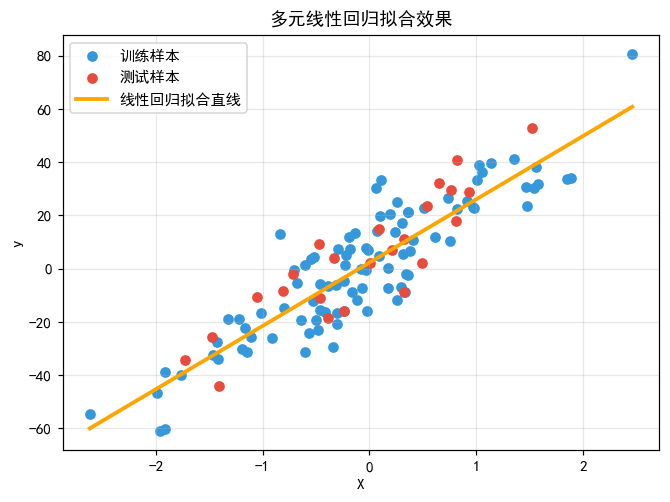

权重W = 23.767, 截距b = 2.200
测试集MSE: 121.29
测试集R²: 0.775


In [2]:
np.random.seed(42)
X, y = make_regression(n_samples=120, n_features=1, noise=12, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# 绘图
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, label="训练样本", color="#3498db")
plt.scatter(X_test, y_test, label="测试样本", color="#e74c3c")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
plt.plot(x_line, lr.predict(x_line), lw=2.5, color="orange", label="线性回归拟合直线")
plt.xlabel("X")
plt.ylabel("y")
plt.title("多元线性回归拟合效果")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"权重W = {lr.coef_[0]:.3f}, 截距b = {lr.intercept_:.3f}")
print(f"测试集MSE: {mean_squared_error(y_test,y_pred):.2f}")
print(f"测试集R²: {r2_score(y_test,y_pred):.3f}")

### 2.1.2 岭回归 Ridge（L2正则线性回归）
损失函数：
$$J = \frac{1}{2N}\sum(\hat{y}-y)^2 + \frac{\lambda}{2}\|W\|_2^2$$
作用：L2正则约束权重大小，缓解特征多重共线性，防止权重爆炸；权重趋向0但不会等于0。

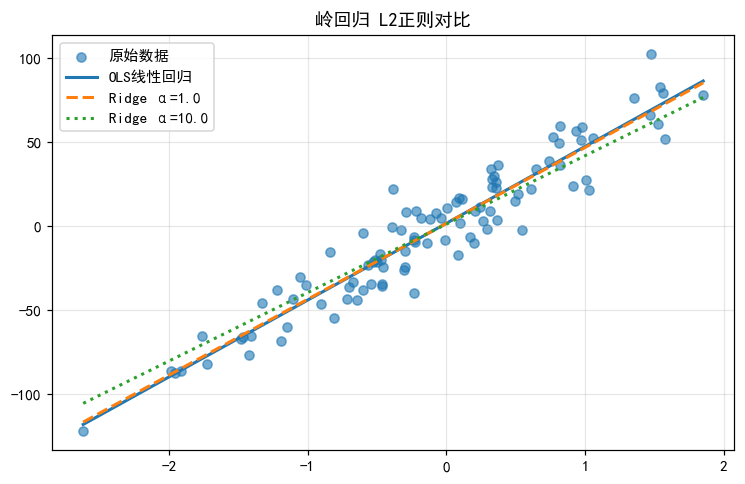

In [3]:
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
# 对比普通线性回归与不同alpha岭回归
plt.figure(figsize=(8,5))
plt.scatter(X, y, alpha=0.6, label="原始数据")
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)

model_ols = LinearRegression().fit(X,y)
plt.plot(x_range, model_ols.predict(x_range), label="OLS线性回归", lw=2)

ridge1 = Ridge(alpha=1.0).fit(X,y)
plt.plot(x_range, ridge1.predict(x_range), label="Ridge α=1.0", lw=2, linestyle="--")

ridge10 = Ridge(alpha=10.0).fit(X,y)
plt.plot(x_range, ridge10.predict(x_range), label="Ridge α=10.0", lw=2, linestyle=":")

plt.title("岭回归 L2正则对比")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2.1.3 Lasso回归（L1正则线性回归）
损失函数：
$$J = \frac{1}{2N}\sum(\hat{y}-y)^2 + \lambda\|W\|_1$$
特点：L1正则在原点次梯度不连续，可以将冗余特征权重压缩至0，实现**自动特征筛选**，生成稀疏模型。

Lasso各特征权重：
特征0 weight = 1.762
特征1 weight = -1.311
特征2 weight = 0.000
特征3 weight = -0.000
特征4 weight = 0.000
特征5 weight = 0.000
特征6 weight = -0.000
特征7 weight = -0.000


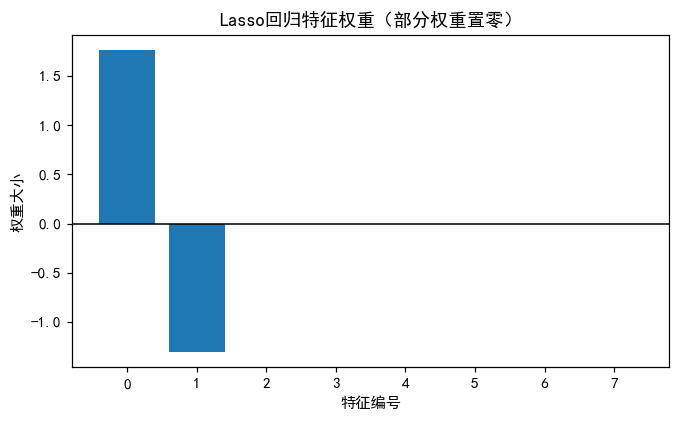

In [4]:
# 构造高维数据，仅前2个特征有效，验证特征稀疏效果
np.random.seed(42)
X_high = np.random.randn(150, 8)
y_high = 2.2*X_high[:,0] - 1.5*X_high[:,1] + np.random.randn(150)*0.8

lasso = Lasso(alpha=0.3)
lasso.fit(X_high, y_high)

# 输出权重，可以观察大量权重趋近0
print("Lasso各特征权重：")
for idx,w in enumerate(lasso.coef_):
    print(f"特征{idx} weight = {w:.3f}")

# 可视化权重分布
plt.figure(figsize=(7,4))
plt.bar(range(len(lasso.coef_)), lasso.coef_)
plt.axhline(y=0,color="black",lw=1)
plt.xlabel("特征编号")
plt.ylabel("权重大小")
plt.title("Lasso回归特征权重（部分权重置零）")
plt.show()

### 2.1.4 多项式回归
对原始特征构造高次项，参数仍然线性；单变量二次形式：
$$\hat{y}=w_0 + w_1 x + w_2 x^2$$
风险：阶数过高极易产生过拟合，实践中必须搭配正则约束。

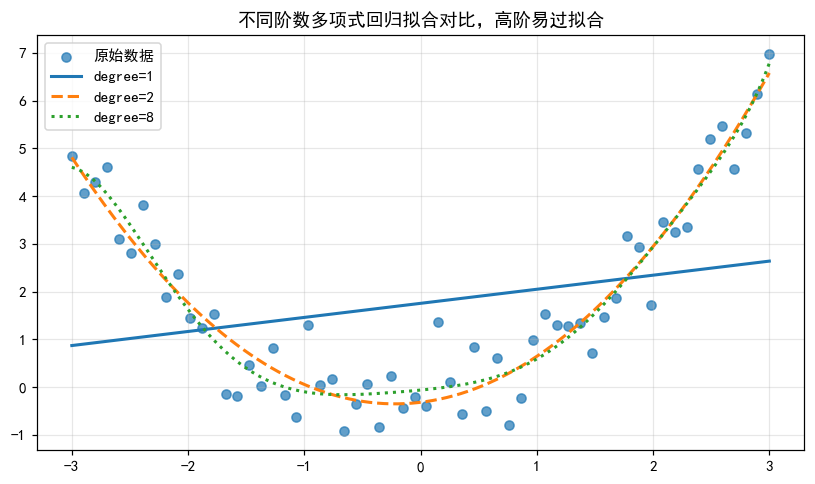

In [5]:
np.random.seed(42)
x_raw = np.linspace(-3,3,60)
y_raw = 0.6*x_raw**2 + 0.3*x_raw + np.random.randn(60)*0.7
X = x_raw.reshape(-1,1)

plt.figure(figsize=(9,5))
plt.scatter(x_raw, y_raw, label="原始数据", alpha=0.7)

# 1阶（线性）、2阶、8阶多项式对比
for degree, ls in zip([1,2,8], ["-","--",":"]):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("lr", LinearRegression())
    ])
    pipe.fit(X, y_raw)
    x_plot = np.linspace(-3,3,200).reshape(-1,1)
    plt.plot(x_plot, pipe.predict(x_plot), label=f"degree={degree}", linestyle=ls, lw=2)

plt.title("不同阶数多项式回归拟合对比，高阶易过拟合")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2.1.5 逻辑回归（二分类广义线性模型）
$$z=W^Tx+b,\quad \hat{y}=\sigma(z)=\frac{1}{1+e^{-z}}$$
使用二元交叉熵损失，不存在解析闭式解；多分类任务拓展为Softmax回归。

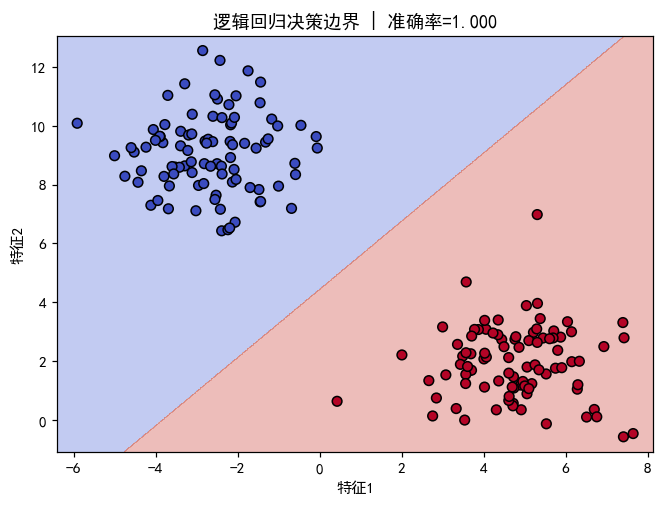

In [6]:
# 生成二分类数据集
X_cls, y_cls = make_blobs(n_samples=180, centers=2, random_state=42, cluster_std=1.3)
X_train, X_test, y_train, y_test = train_test_split(X_cls,y_cls,test_size=0.2,random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
acc = accuracy_score(y_test,y_pred)

plot_decision_boundary(log_reg, X_cls, y_cls, f"逻辑回归决策边界 | 准确率={acc:.3f}")

### 2.2.1 K近邻 KNN
惰性模型，无显式训练过程；预测时选取距离最近k个样本投票/均值。
欧氏距离：
$$d(x_1,x_2)=\sqrt{\sum_{j=1}^D (x_{1j}-x_{2j})^2}$$
超参k：k过小→过拟合；k过大→欠拟合；预测速度慢。

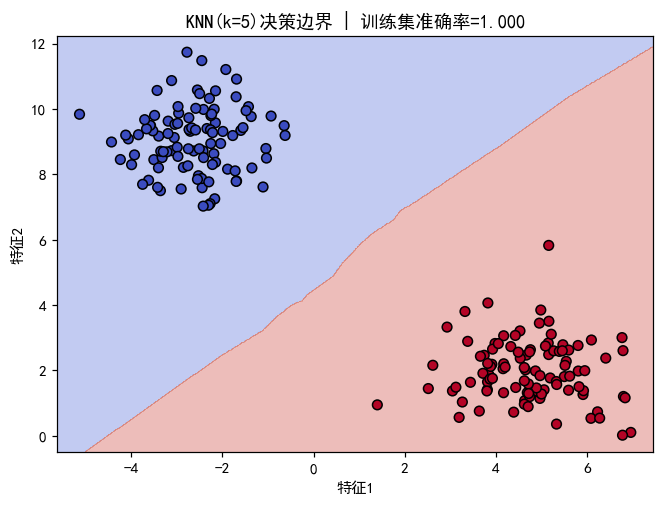

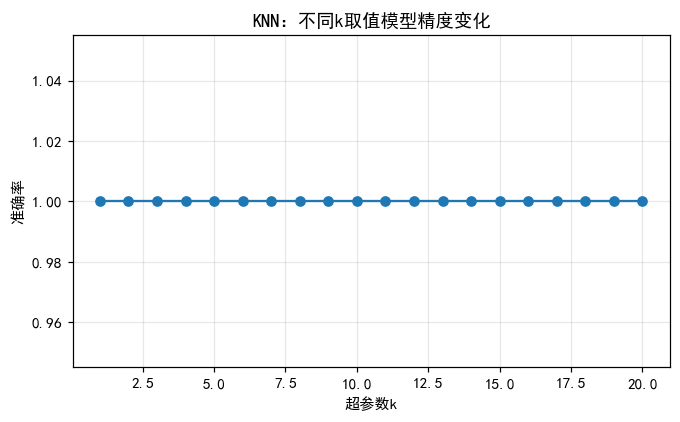

In [7]:
X_blobs, y_blobs = make_blobs(n_samples=200, centers=2, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_blobs,y_blobs)
acc = knn.score(X_blobs,y_blobs)
plot_decision_boundary(knn, X_blobs, y_blobs, f"KNN(k=5)决策边界 | 训练集准确率={acc:.3f}")

# 绘制K值与准确率曲线（超参选择可视化）
k_list = range(1,21)
acc_list = []
for k in k_list:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_blobs,y_blobs)
    acc_list.append(model.score(X_blobs,y_blobs))

plt.figure(figsize=(7,4))
plt.plot(k_list, acc_list, marker="o")
plt.xlabel("超参数k")
plt.ylabel("准确率")
plt.title("KNN：不同k取值模型精度变化")
plt.grid(alpha=0.3)
plt.show()

### 2.2.2 朴素贝叶斯
贝叶斯公式 + 特征条件独立假设：
$$P(Y|X)=\frac{P(X|Y)P(Y)}{P(X)},\quad P(X_1,X_2|Y)=P(X_1|Y)P(X_2|Y)$$
高斯朴素贝叶斯适配连续特征；多项式朴素贝叶斯多用于文本分类；训练速度极快。

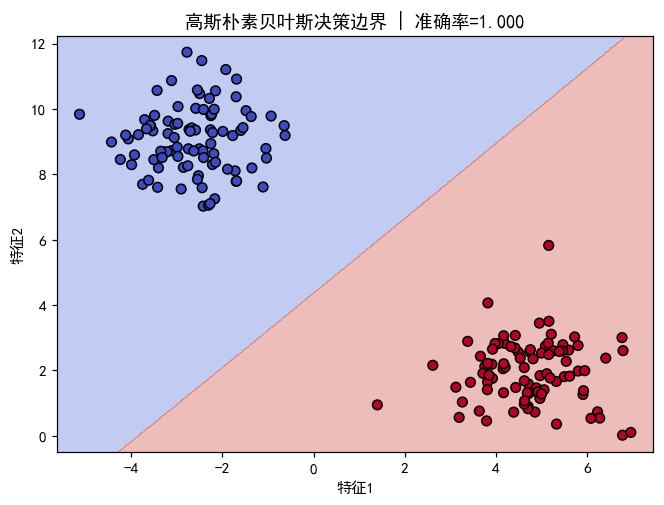

In [9]:
X_nb, y_nb = make_blobs(n_samples=180, centers=2, random_state=42)
gnb = GaussianNB()
gnb.fit(X_nb, y_nb)
acc = gnb.score(X_nb,y_nb)
plot_decision_boundary(gnb, X_nb, y_nb, f"高斯朴素贝叶斯决策边界 | 准确率={acc:.3f}")

### 2.3.1 决策树
递归划分特征空间；分类分裂准则信息熵：
$$H = -\sum_c p_c \log p_c$$
抑制过拟合手段：限制树深、叶子最小样本数量；模型可解释性强。

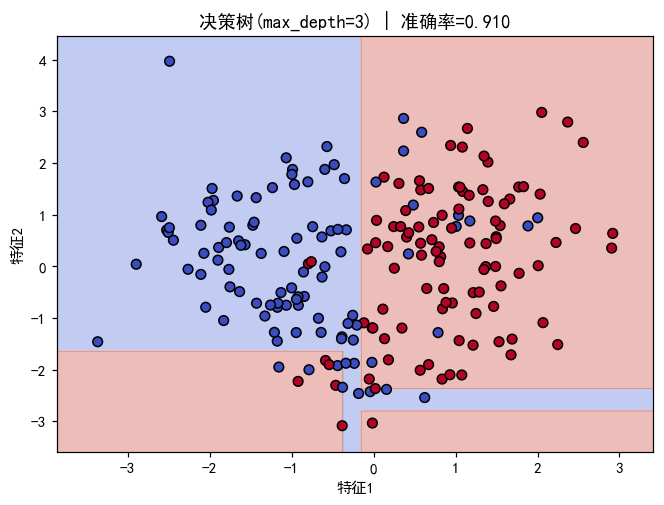

In [10]:
X_dt, y_dt = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=42)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_dt,y_dt)
acc = dt.score(X_dt,y_dt)
plot_decision_boundary(dt, X_dt, y_dt, f"决策树(max_depth=3) | 准确率={acc:.3f}")

### 2.3.2 随机森林
并行训练多棵独立决策树，样本随机采样、特征随机采样；预测投票输出，降低单棵决策树方差。

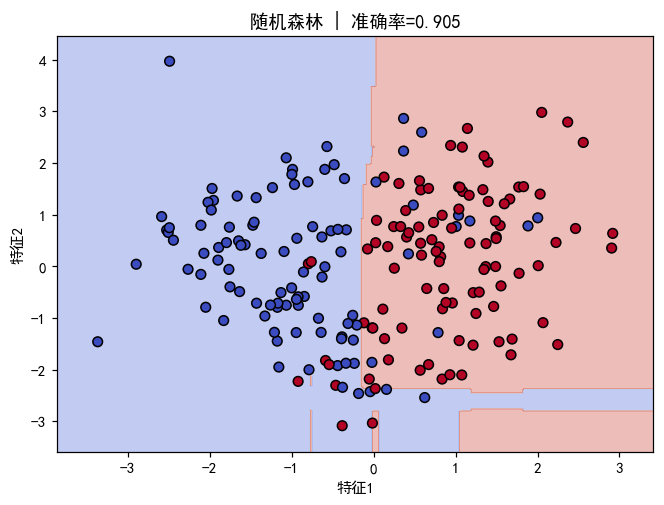

In [11]:
rf = RandomForestClassifier(n_estimators=30, max_depth=3, random_state=42)
rf.fit(X_dt,y_dt)
acc = rf.score(X_dt,y_dt)
plot_decision_boundary(rf, X_dt, y_dt, f"随机森林 | 准确率={acc:.3f}")

### 2.3.3 GBDT/XGBoost/LightGBM
串行训练，每一棵树拟合前一轮预测残差；目标函数内置L2正则；表格结构化数据首选基础模型。

D:\anaconda\lib\site-packages\xgboost\core.py:158: UserWarning: [01:40:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


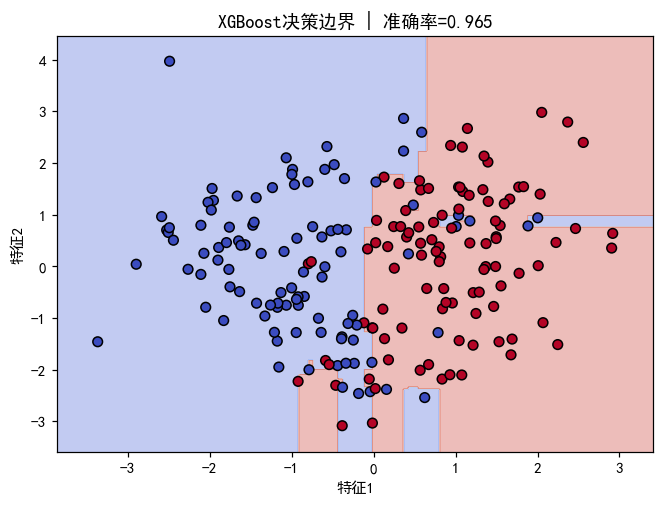

In [12]:
# XGBoost示例
xgb_model = xgb.XGBClassifier(n_estimators=25, max_depth=3, random_state=42, use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_dt,y_dt)
acc = xgb_model.score(X_dt,y_dt)
plot_decision_boundary(xgb_model, X_dt, y_dt, f"XGBoost决策边界 | 准确率={acc:.3f}")

### 2.4 PCA主成分分析
线性无监督降维算法；求解协方差矩阵 $X^TX$ 的特征值、特征向量；选取前k个最大特征向量作为投影基，保留数据最大方差，去除特征冗余、用于高维数据可视化。

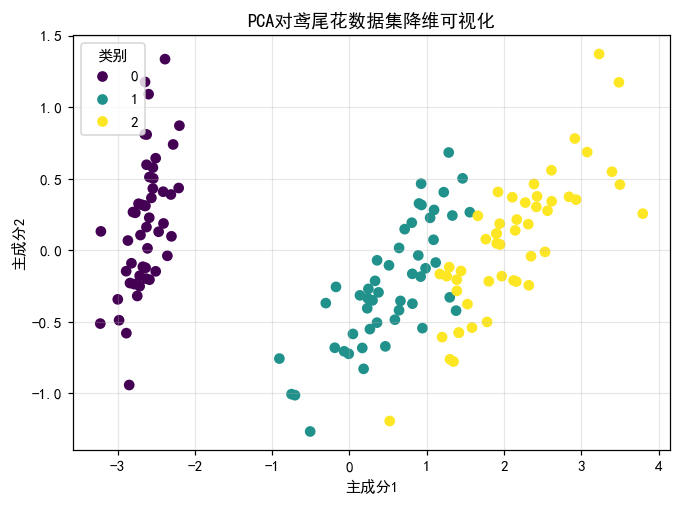

前两个主成分方差保留比例：0.978


In [13]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# PCA降到二维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_iris, cmap="viridis")
plt.xlabel("主成分1")
plt.ylabel("主成分2")
plt.title("PCA对鸢尾花数据集降维可视化")
plt.legend(*scatter.legend_elements(), title="类别")
plt.grid(alpha=0.3)
plt.show()
print(f"前两个主成分方差保留比例：{sum(pca.explained_variance_ratio_):.3f}")

### 2.5.1 单层感知机
$$\hat{y}=\text{sign}(Wx+b)$$
仅能处理线性可分样本，无法解决异或这类非线性问题。

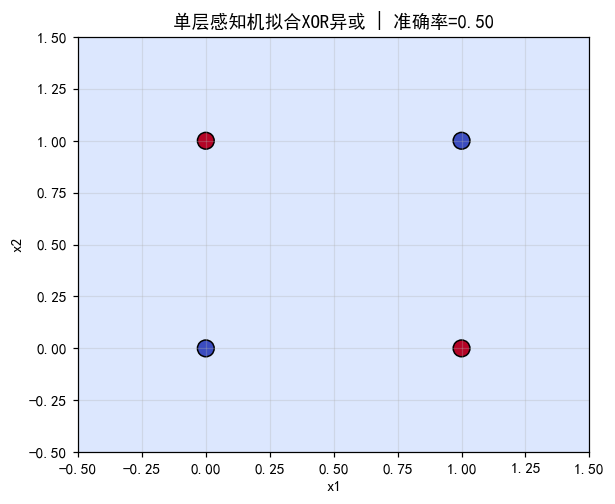

结论：单层感知机无法拟合异或非线性问题


In [16]:
from sklearn.linear_model import Perceptron

# 构造XOR异或数据集
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

perceptron = Perceptron(max_iter=1000, random_state=42)
perceptron.fit(X, y)
acc = perceptron.score(X, y)

plt.figure(figsize=(6,5))
# 生成网格
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min,x_max,100),
                     np.linspace(y_min,y_max,100))
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X[:,0], X[:,1], c=y, s=120, edgecolors="black", cmap="coolwarm")
plt.title(f"单层感知机拟合XOR异或 | 准确率={acc:.2f}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.show()
print("结论：单层感知机无法拟合异或非线性问题")

### 2.5.2 MLP多层全连接网络
多层线性变换叠加非线性激活函数；万能逼近定理：理论上可以拟合任意连续函数。训练流程：前向传播计算预测，反向传播梯度下降优化；常用ReLU激活、Dropout抑制过拟合。

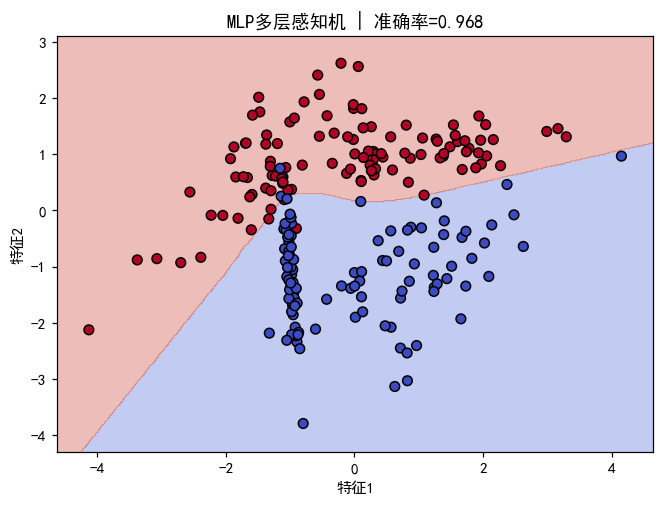

In [14]:
mlp = MLPClassifier(hidden_layer_sizes=(20,10), activation="relu", max_iter=600, random_state=42)
X_nn, y_nn = make_classification(n_samples=220, n_features=2, n_informative=2, n_redundant=0, random_state=42)
mlp.fit(X_nn,y_nn)
acc = mlp.score(X_nn,y_nn)
plot_decision_boundary(mlp, X_nn, y_nn, f"MLP多层感知机 | 准确率={acc:.3f}")

### 2.5.3 CNN卷积神经网络
核心操作：卷积运算、池化下采样；卷积层权重共享，大幅减少参数量；面向图像网格数据，分层提取局部视觉特征。
> 本入门示例不作大规模图像训练，原理代码注释说明，可拓展MNIST手写数字识别。

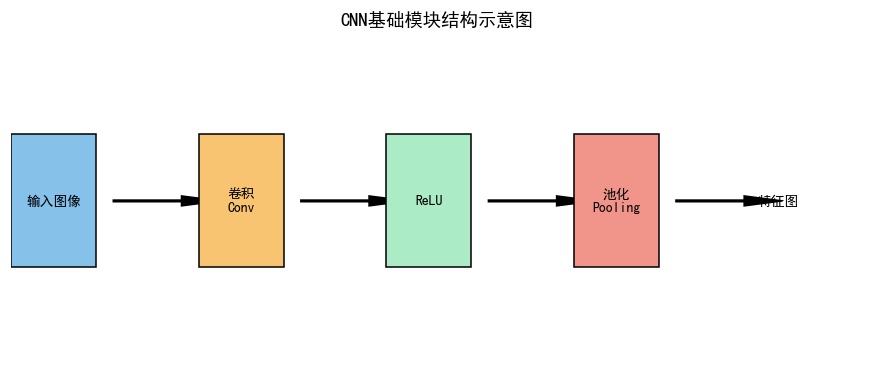

In [17]:
plt.figure(figsize=(10,4))
# 简单绘制CNN数据流示意图
from matplotlib.patches import Rectangle

ax = plt.gca()
ax.set_xlim(0,10)
ax.set_ylim(0,10)
ax.axis("off")

# 输入图像
rect1 = Rectangle((0,3),1,4,ec="black",fc="#85c1e9")
ax.add_patch(rect1)
ax.text(0.5, 5, "输入图像",ha="center",va="center",fontsize=9)

# 箭头
ax.arrow(1.2,5,0.8,0,width=0.05,head_width=0.3,color="k")

# 卷积层
rect2 = Rectangle((2.2,3),1,4,ec="black",fc="#f8c471")
ax.add_patch(rect2)
ax.text(2.7, 5, "卷积\nConv",ha="center",va="center",fontsize=9)

ax.arrow(3.4,5,0.8,0,width=0.05,head_width=0.3,color="k")

# ReLU激活
rect3 = Rectangle((4.4,3),1,4,ec="black",fc="#abebc6")
ax.add_patch(rect3)
ax.text(4.9, 5, "ReLU",ha="center",va="center",fontsize=9)

ax.arrow(5.6,5,0.8,0,width=0.05,head_width=0.3,color="k")

# 池化层
rect4 = Rectangle((6.6,3),1,4,ec="black",fc="#f1948a")
ax.add_patch(rect4)
ax.text(7.1, 5, "池化\nPooling",ha="center",va="center",fontsize=9)

ax.arrow(7.8,5,0.8,0,width=0.05,head_width=0.3,color="k")
ax.text(9,5,"特征图",ha="center",va="center",fontsize=9)

plt.title("CNN基础模块结构示意图")
plt.show()

### 2.5.4 RNN/LSTM时序循环网络
时序递推公式：
$$h_t=\sigma(W_h h_{t-1}+W_x x_t + b)$$
基础RNN存在长序列梯度消失问题；LSTM依靠输入门、遗忘门、输出门捕获长期时序依赖，适配文本、时间序列预测。

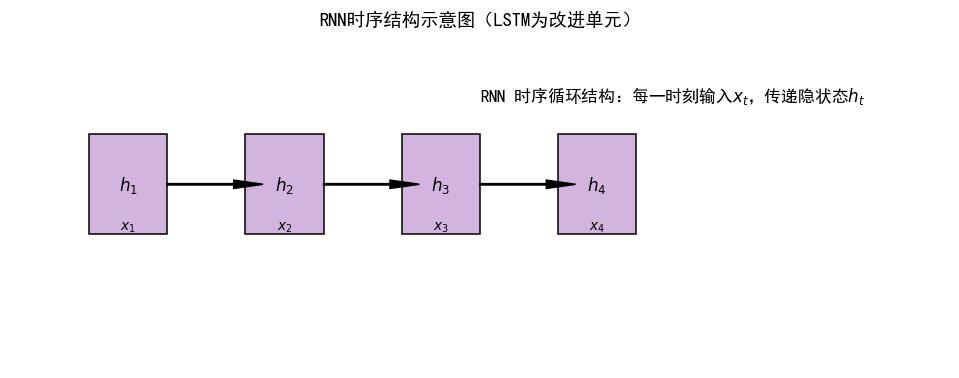

In [18]:
plt.figure(figsize=(11,4))
ax = plt.gca()
ax.set_xlim(0,12)
ax.set_ylim(0,10)
ax.axis("off")
from matplotlib.patches import Rectangle

pos_x = [1,3,5,7]
for i,x in enumerate(pos_x):
    rect = Rectangle((x,4),1,3,ec="black",fc="#d2b4de")
    ax.add_patch(rect)
    ax.text(x+0.5,5.5,f"$h_{i+1}$",ha="center",va="center",fontsize=11)
    ax.text(x+0.5,4.2,f"$x_{i+1}$",ha="center",va="center",fontsize=9)

# 横向时序箭头
for i in range(len(pos_x)-1):
    start_x = pos_x[i]+1
    end_x = pos_x[i+1]
    ax.arrow(start_x,5.5, end_x-start_x-0.15,0,width=0.04,head_width=0.25,color="black")

plt.text(6, 8, "RNN 时序循环结构：每一时刻输入$x_t$，传递隐状态$h_t$", fontsize=11)
plt.title("RNN时序结构示意图（LSTM为改进单元）")
plt.show()

### 2.6.1 Q-learning
贝尔曼更新公式：
$$Q(s,a) \leftarrow Q(s,a)+\alpha\left[R+\gamma\max_{a'}Q(s',a')-Q(s,a)\right]$$
$\alpha$学习率，$\gamma$折扣因子；基于价值的无模型强化学习。

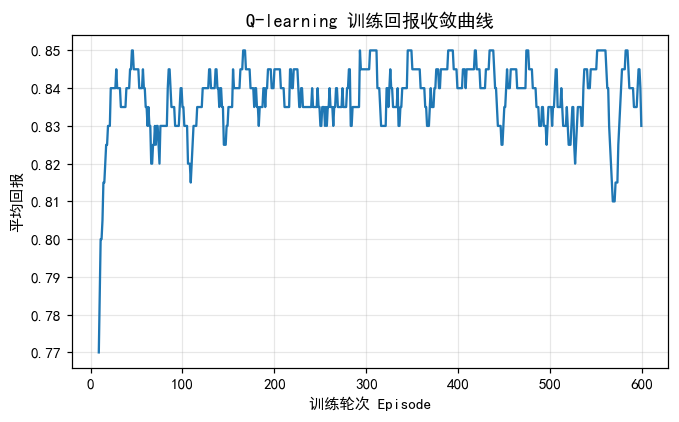

In [15]:
# 简易一维环境Q-learning，可视化训练回报曲线
np.random.seed(42)
n_states = 5
n_actions = 2
Q = np.zeros((n_states, n_actions))
alpha = 0.1
gamma = 0.9
epsilon = 0.1
episode_reward = []

for ep in range(600):
    state = 0
    total_r = 0
    for _ in range(30):
        # epsilon-greedy
        if np.random.rand() < epsilon:
            act = np.random.randint(0,n_actions)
        else:
            act = np.argmax(Q[state])
        next_state = (state + act) % n_states
        reward = 1 if next_state == n_states-1 else -0.05
        # Q更新
        Q[state,act] += alpha*(reward + gamma*np.max(Q[next_state]) - Q[state,act])
        state = next_state
        total_r += reward
        if state == n_states-1:
            break
    episode_reward.append(total_r)

# 绘图
plt.figure(figsize=(7,4))
plt.plot(pd.Series(episode_reward).rolling(window=10).mean())
plt.xlabel("训练轮次 Episode")
plt.ylabel("平均回报")
plt.title("Q-learning 训练回报收敛曲线")
plt.grid(alpha=0.3)
plt.show()

### 2.6.2 Policy Gradient 策略梯度
不拟合价值函数，直接优化动作概率分布，最大化长期累积回报；适合连续动作空间任务。

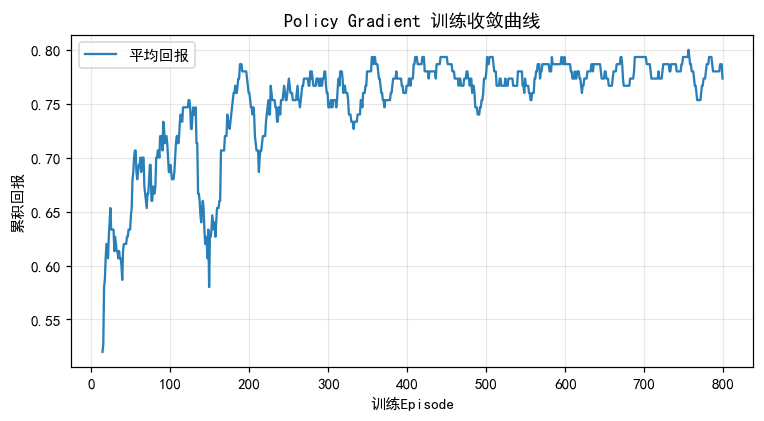

In [19]:
import numpy as np

# 简易一维环境
np.random.seed(42)
# 参数
state_num = 4
action_num = 2
theta = np.random.randn(state_num, action_num)
lr = 0.08
gamma = 0.95
episode_total = 800
reward_history = []

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def get_action(state):
    prob = softmax(theta[state])
    return np.random.choice(action_num, p=prob)

for ep in range(episode_total):
    state = 0
    trajectory = []
    total_r = 0
    # 交互收集轨迹
    for _ in range(25):
        a = get_action(state)
        next_s = (state + a) % state_num
        r = 1 if next_s == state_num-1 else -0.1
        trajectory.append((state,a,r))
        total_r += r
        state = next_s
        if state == state_num-1:
            break
    reward_history.append(total_r)

    # 策略梯度更新
    G = 0
    grad = np.zeros_like(theta)
    for s,a,r in reversed(trajectory):
        G = r + gamma * G
        prob = softmax(theta[s])
        for act in range(action_num):
            if act == a:
                grad[s,act] += G * (1-prob[act])
            else:
                grad[s,act] += G * (-prob[act])
    theta += lr * grad

# 绘图：回报收敛曲线
plt.figure(figsize=(8,4))
# 滑动平均平滑曲线
smooth_reward = pd.Series(reward_history).rolling(window=15).mean()
plt.plot(smooth_reward, color="#2980b9", label="平均回报")
plt.xlabel("训练Episode")
plt.ylabel("累积回报")
plt.title("Policy Gradient 训练收敛曲线")
plt.legend()
plt.grid(alpha=0.3)
plt.show()